# XGBoost Hyperparameter Tuning (exploration)

Compares **grid search**, **random search**, and **Bayesian optimization (Optuna)**
for tuning XGBoost on the streamflow feature matrix.

A summary section compares all three methods on CV RMSE, test RMSE, test
NSE, wall-clock time, and convergence speed. This notebook is standalone
exploration and does not log to MLflow -- for tracked, reproducible runs
use `streamflow.tune` (the same three methods) and `streamflow.train`.

**Before running:** make sure `xgboost`, `scikit-learn`, and `optuna` are
installed. There's no DVC remote configured for this repo, so the cell below
runs the ingest + feature-engineering pipeline directly instead of `dvc pull`
to materialize the feature parquet.

## Setup

In [1]:
import time

import numpy as np
import pandas as pd
import xgboost as xgb
import optuna
from sklearn.model_selection import (
    TimeSeriesSplit,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
)
from sklearn.metrics import mean_absolute_error
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error as _mse

    def root_mean_squared_error(y_true, y_pred):
        return _mse(y_true, y_pred) ** 0.5


def nash_sutcliffe_efficiency(y_true, y_pred):
    """NSE = 1 - SS_res/SS_tot: standard hydrology goodness-of-fit metric.
    NSE=1 is a perfect model, NSE=0 means no better than predicting the
    observed mean, NSE<0 means worse than the mean. Numerically identical
    to sklearn's r2_score, computed explicitly here for the domain framing."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot

In [2]:
# Config
FEATURE_PARQUET = "data/features/feature_matrix.parquet"
N_TRIALS = 40              # trial budget -- kept equal across methods for a fair comparison
CV_FOLDS = 5
RANDOM_STATE = 42

## 0. Data

Runs pipeline to get data

In [3]:
import sys
from pathlib import Path

repo_root = Path.cwd().parent  # notebooks/ -> repo root
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Running ingest + feature engineering to materialize feature data...")

from streamflow import ingest, features

ingest.build_and_save()
features.build_and_save()

Running ingest + feature engineering to materialize feature data...
fetching USGS streamflow...
  usgs page 3: 30,254 records
  30,162 daily values, 1944-01-01 -> 2026-07-30
fetching Open-Meteo weather...
  30,162 daily weather rows

saved 30,162 rows -> C:\Users\swtak\Documents\MLOps\Final Project\streamflow-mlops\data\raw\streamflow.parquet
  provisional: 60 | missing weather: 0
saved 30,131 feature rows -> C:\Users\swtak\Documents\MLOps\Final Project\streamflow-mlops\data\features\feature_matrix.parquet
target: target_log_streamflow_next_day | features: 49


,date,streamflow_cfs,approval_status,qualifier,last_modified,precip_mm,tmax_c,tmin_c,target_streamflow_next_day,target_log_streamflow_next_day,...,precip_sum_30d,precip_mean_30d,temp_mean_c,temp_range_c,temp_mean_roll_7d,temp_mean_roll_30d,day_of_year_sin,day_of_year_cos,month,is_high_flow_anomaly
0,1944-01-31,54.0,Approved,None,2025-02-24 12:43:19.306975+00:00,9.2,2.5,-3.0,52.0,3.970292,...,34.4,1.146667,-0.25,5.5,4.257143,-0.596667,0.508356,0.861147,1,0
1,1944-02-01,52.0,Approved,None,2025-02-24 12:43:19.306975+00:00,0.0,-0.1,-5.7,49.0,3.912023,...,34.4,1.146667,-2.90,5.6,2.700000,-0.671667,0.523094,0.852275,2,0
2,1944-02-02,49.0,Approved,None,2025-02-24 12:43:19.306975+00:00,0.5,2.3,-4.9,42.0,3.761200,...,34.9,1.163333,-1.30,7.2,1.442857,-0.716667,0.537677,0.843151,2,0
3,1944-02-03,42.0,Approved,None,2025-02-24 12:43:19.306975+00:00,0.0,6.5,-5.3,45.0,3.828641,...,34.9,1.163333,0.60,11.8,0.185714,-0.696667,0.552101,0.833777,2,0
4,1944-02-04,45.0,Approved,None,2025-02-24 12:43:19.306975+00:00,0.0,4.6,-3.5,56.0,4.043051,...,32.8,1.093333,0.55,8.1,-0.271429,-0.650000,0.566362,0.824157,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30126,2026-07-25,168.0,Provisional,None,2026-07-26 08:09:36.358511+00:00,0.0,26.9,16.3,181.0,5.204007,...,86.2,2.873333,21.60,10.6,21.471429,25.051667,-0.391358,-0.920239,7,0
30127,2026-07-26,181.0,Provisional,None,2026-07-27 08:09:56.094231+00:00,1.2,34.1,21.2,1030.0,6.938284,...,85.6,2.853333,27.65,12.9,22.250000,25.398333,-0.407129,-0.913370,7,0
30128,2026-07-27,1030.0,Provisional,None,2026-07-29 08:09:14.918806+00:00,26.3,27.4,23.2,2020.0,7.611348,...,111.9,3.730000,25.30,4.2,22.750000,25.545000,-0.422781,-0.906232,7,0
30129,2026-07-28,2020.0,Provisional,None,2026-07-29 08:09:14.918806+00:00,0.1,25.2,20.0,1100.0,7.003974,...,111.6,3.720000,22.60,5.2,22.435714,25.530000,-0.438307,-0.898825,7,0


In [4]:
from streamflow.tune import load_data

X_train, X_test, y_train, y_test, feature_columns = load_data()

print(f"Loaded {len(feature_columns)} features, train={len(X_train)}, test={len(X_test)}")
X_train.head()

Loaded 49 features, train=25582, test=4519


,precip_mm,tmax_c,tmin_c,streamflow_t,log_streamflow_t,streamflow_lag_1,log_streamflow_lag_1,streamflow_lag_2,log_streamflow_lag_2,streamflow_lag_3,...,precip_sum_30d,precip_mean_30d,temp_mean_c,temp_range_c,temp_mean_roll_7d,temp_mean_roll_30d,day_of_year_sin,day_of_year_cos,month,is_high_flow_anomaly
0,9.2,2.5,-3.0,54.0,4.007333,80.0,4.394449,64.0,4.174387,60.0,...,34.4,1.146667,-0.25,5.5,4.257143,-0.596667,0.508356,0.861147,1,0
1,0.0,-0.1,-5.7,52.0,3.970292,54.0,4.007333,80.0,4.394449,64.0,...,34.4,1.146667,-2.90,5.6,2.700000,-0.671667,0.523094,0.852275,2,0
2,0.5,2.3,-4.9,49.0,3.912023,52.0,3.970292,54.0,4.007333,80.0,...,34.9,1.163333,-1.30,7.2,1.442857,-0.716667,0.537677,0.843151,2,0
3,0.0,6.5,-5.3,42.0,3.761200,49.0,3.912023,52.0,3.970292,54.0,...,34.9,1.163333,0.60,11.8,0.185714,-0.696667,0.552101,0.833777,2,0
4,0.0,4.6,-3.5,45.0,3.828641,42.0,3.761200,49.0,3.912023,52.0,...,32.8,1.093333,0.55,8.1,-0.271429,-0.650000,0.566362,0.824157,2,0


## Shared helper -- fit final model on best params

In [5]:
def eval_final_model(params):
    """Fit final model with best params on full train set, return test RMSE/MAE/NSE."""
    model = xgb.XGBRegressor(
        **params,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    rmse = root_mean_squared_error(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    nse = nash_sutcliffe_efficiency(y_test, preds)

    return rmse, mae, nse

## 1. Grid search

Restricted grid — a full 6-parameter grid explodes combinatorially, so this
grids over `max_depth` + `min_child_weight` (the pair that interacts most,
per the redundancy discussion) plus `subsample`/`colsample_bytree`, holding
`learning_rate`, `n_estimators`, and `reg_lambda` fixed.

In [6]:
def run_grid_search():
    param_grid = {
        "max_depth": [3, 5, 7, 9],
        "min_child_weight": [1, 3, 5],
        "subsample": [0.7, 0.85, 1.0],
        "colsample_bytree": [0.7, 0.85, 1.0],
    }

    base_model = xgb.XGBRegressor(
        objective="reg:squarederror",
        learning_rate=0.05,
        n_estimators=300,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    start = time.time()
    search = GridSearchCV(
        base_model,
        param_grid,
        scoring="neg_root_mean_squared_error",
        cv=TimeSeriesSplit(n_splits=CV_FOLDS),
        n_jobs=-1,
        verbose=1,
    )
    search.fit(X_train, y_train)
    elapsed = time.time() - start

    results = search.cv_results_
    best_so_far = np.inf
    convergence = []
    for mean_score in results["mean_test_score"]:
        rmse = -mean_score
        best_so_far = min(best_so_far, rmse)
        convergence.append(best_so_far)

    best_params = {**search.best_params_, "learning_rate": 0.05, "n_estimators": 300, "reg_lambda": 1.0}
    test_rmse, mae, nse = eval_final_model(best_params)

    print(f"[Grid Search] best CV RMSE={-search.best_score_:.4f}, test RMSE={test_rmse:.4f}, test NSE={nse:.4f}, time={elapsed:.1f}s")
    return {
        "method": "grid_search",
        "best_params": best_params,
        "best_cv_rmse": -search.best_score_,
        "test_rmse": test_rmse,
        "test_nse": nse,
        "time_sec": elapsed,
        "n_trials": len(results["params"]),
        "convergence": convergence,
    }

In [7]:
grid_result = run_grid_search()

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[Grid Search] best CV RMSE=0.2936, test RMSE=0.2622, test NSE=0.9034, time=321.0s


## 2. Random search

Same 5-fold CV, sampling `N_TRIALS` random draws from a wider distribution
that also includes `reg_lambda` and `learning_rate`.

In [8]:
def run_random_search():
    param_distributions = {
        "max_depth": np.arange(3, 11),
        "min_child_weight": np.arange(1, 8),
        "subsample": np.linspace(0.6, 1.0, 9),
        "colsample_bytree": np.linspace(0.6, 1.0, 9),
        "reg_lambda": np.logspace(-2, 2, 20),
        "learning_rate": np.logspace(-2.3, -0.7, 15),  # ~0.005 to ~0.2
    }

    base_model = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    start = time.time()
    search = RandomizedSearchCV(
        base_model,
        param_distributions,
        n_iter=N_TRIALS,
        scoring="neg_root_mean_squared_error",
        cv=TimeSeriesSplit(n_splits=CV_FOLDS),
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=1,
    )
    search.fit(X_train, y_train)
    elapsed = time.time() - start

    results = search.cv_results_
    best_so_far = np.inf
    convergence = []
    for mean_score in results["mean_test_score"]:
        rmse = -mean_score
        best_so_far = min(best_so_far, rmse)
        convergence.append(best_so_far)

    best_params = {**search.best_params_, "n_estimators": 300}
    test_rmse, mae, nse = eval_final_model(best_params)

    print(f"[Random Search] best CV RMSE={-search.best_score_:.4f}, test RMSE={test_rmse:.4f}, test NSE={nse:.4f}, time={elapsed:.1f}s")
    return {
        "method": "random_search",
        "best_params": best_params,
        "best_cv_rmse": -search.best_score_,
        "test_rmse": test_rmse,
        "test_nse": nse,
        "time_sec": elapsed,
        "n_trials": N_TRIALS,
        "convergence": convergence,
    }

In [9]:
random_result = run_random_search()

Fitting 5 folds for each of 40 candidates, totalling 200 fits
[Random Search] best CV RMSE=0.2938, test RMSE=0.2620, test NSE=0.9036, time=128.6s


## 3. Bayesian optimization (Optuna)

Uses Optuna's TPE sampler with the same search space as random search.

In [10]:
def run_bayesian_search():
    def objective(trial):
        params = {
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 7),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 1e2, log=True),
            "learning_rate": trial.suggest_float("learning_rate", 5e-3, 2e-1, log=True),
        }
        model = xgb.XGBRegressor(
            **params,
            objective="reg:squarederror",
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        scores = cross_val_score(
            model, X_train, y_train,
            scoring="neg_root_mean_squared_error",
            cv=TimeSeriesSplit(n_splits=CV_FOLDS),
            n_jobs=-1,
        )
        return -scores.mean()  # RMSE, minimize

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    )

    start = time.time()
    study.optimize(objective, n_trials=N_TRIALS)
    elapsed = time.time() - start

    convergence = []
    best_so_far = np.inf
    for t in study.trials:
        best_so_far = min(best_so_far, t.value)
        convergence.append(best_so_far)

    best_params = {**study.best_params, "n_estimators": 300}
    test_rmse, mae, nse = eval_final_model(best_params)

    print(f"[Bayesian/Optuna] best CV RMSE={study.best_value:.4f}, test RMSE={test_rmse:.4f}, test NSE={nse:.4f}, time={elapsed:.1f}s")
    return {
        "method": "bayesian_optuna",
        "best_params": best_params,
        "best_cv_rmse": study.best_value,
        "test_rmse": test_rmse,
        "test_nse": nse,
        "time_sec": elapsed,
        "n_trials": N_TRIALS,
        "convergence": convergence,
    }

In [11]:
bayes_result = run_bayesian_search()

[I 2026-07-31 19:19:36,857] A new study created in memory with name: no-name-ab4d70a7-e8d6-4785-b23b-bbd172d84cdc
[I 2026-07-31 19:19:41,379] Trial 0 finished with value: 0.31882125122877863 and parameters: {'max_depth': 5, 'min_child_weight': 7, 'subsample': 0.892797576724562, 'colsample_bytree': 0.8394633936788146, 'reg_lambda': 0.04207988669606638, 'learning_rate': 0.008889607461211927}. Best is trial 0 with value: 0.31882125122877863.
[I 2026-07-31 19:19:43,577] Trial 1 finished with value: 0.29859746707317447 and parameters: {'max_depth': 3, 'min_child_weight': 7, 'subsample': 0.8404460046972835, 'colsample_bytree': 0.8832290311184181, 'reg_lambda': 0.012087541473056965, 'learning_rate': 0.17898794163735265}. Best is trial 1 with value: 0.29859746707317447.
[I 2026-07-31 19:19:59,014] Trial 2 finished with value: 0.3025809134198053 and parameters: {'max_depth': 9, 'min_child_weight': 2, 'subsample': 0.6727299868828402, 'colsample_bytree': 0.6733618039413735, 'reg_lambda': 0.164804

[Bayesian/Optuna] best CV RMSE=0.2932, test RMSE=0.2614, test NSE=0.9040, time=163.6s


## 4. Compare methods

Summary table plus convergence curves (best CV RMSE so far vs trial number) —
the convergence plot is the clearest evidence for whether Bayesian optimization
is actually more sample-efficient than random search on this problem.

In [12]:
results = [grid_result, random_result, bayes_result]

summary_df = pd.DataFrame([
    {
        "method": r["method"],
        "best_cv_rmse": r["best_cv_rmse"],
        "test_rmse": r["test_rmse"],
        "test_nse": r["test_nse"],
        "n_trials": r["n_trials"],
        "time_sec": r["time_sec"],
    }
    for r in results
])

summary_df.to_csv("tuning_comparison.csv", index=False)
summary_df

,method,best_cv_rmse,test_rmse,test_nse,n_trials,time_sec
0,grid_search,0.293614,0.262239,0.903395,108,320.984497
1,random_search,0.293818,0.261964,0.903598,40,128.598318
2,bayesian_optuna,0.293190,0.261393,0.904017,40,163.575104


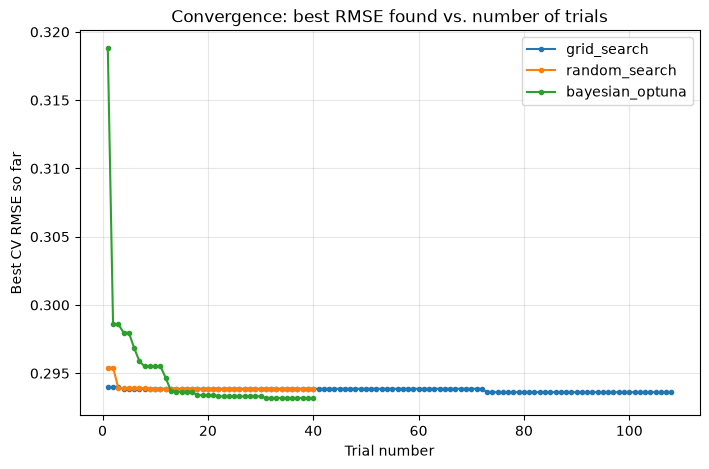

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
for r in results:
    ax.plot(range(1, len(r["convergence"]) + 1), r["convergence"], marker="o", markersize=3, label=r["method"])
ax.set_xlabel("Trial number")
ax.set_ylabel("Best CV RMSE so far")
ax.set_title("Convergence: best RMSE found vs. number of trials")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

This notebook runs standalone and does not log to MLflow, so none of these
runs show up in `mlflow ui` -- that's intentional, so exploratory reruns here
don't clutter the tracking store. Tracked runs come only from
`streamflow.tune` and `streamflow.train` (the pipeline scripts), which log
every trial and the final model.

## Unit tests

The functions in streamflow/tune.py (`load_data`, `compute_convergence`,
`eval_and_log_final_model`, `run_grid_search`, `run_random_search`,
`run_bayesian_search`, `summarize`, `save_best_params`, `ensure_data_pulled`)
are covered by `tests/test_xgboost.py`, which runs against tiny synthetic data
and a temp MLflow tracking store (see `tests/conftest.py`) -- it does not touch
the real dataset or your real `mlruns` folder.

Run it from a terminal at the repo root:
```
pytest tests/test_xgboost.py -v
```
Or run it from a cell here:

In [15]:
# import sys
import subprocess

result = subprocess.run(
    [sys.executable, "-m", "pytest", str(repo_root / "tests" / "test_xgboost.py"), "-v"],
    capture_output=True, text=True,
)
print(result.stdout[-3000:])
print(result.stderr[-1000:])

48%]
..\tests\test_xgboost.py::test_eval_and_log_final_model_returns_finite_metrics_and_logs_a_run PASSED [ 52%]
..\tests\test_xgboost.py::test_eval_and_log_final_model_extra_tags_are_logged PASSED [ 56%]
..\tests\test_xgboost.py::test_run_grid_search_returns_expected_result_contract PASSED [ 60%]
..\tests\test_xgboost.py::test_run_grid_search_convergence_is_non_increasing PASSED [ 64%]
..\tests\test_xgboost.py::test_run_random_search_returns_expected_result_contract PASSED [ 68%]
..\tests\test_xgboost.py::test_run_bayesian_search_returns_expected_result_contract PASSED [ 72%]
..\tests\test_xgboost.py::test_run_bayesian_search_convergence_never_increases PASSED [ 76%]
..\tests\test_xgboost.py::test_summarize_dataframe_has_one_row_per_method PASSED [ 80%]
..\tests\test_xgboost.py::test_summarize_best_method_by_cv_rmse_is_identifiable PASSED [ 84%]
..\tests\test_xgboost.py::test_summarize_writes_csv_artifact PASSED      [ 88%]
..\tests\test_xgboost.py::test_summarize_logs_a_summary_run_t